### Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

### Exploration And Importing DF

#### Data Frame

In [12]:
## Import the dataset
# from google.colab import files
# import io

# Upload file manually
# uploaded = files.upload()

# Read it using the filename
# filename = list(uploaded.keys())[0]  # automatically gets the uploaded filename
# df = pd.read_excel(io.BytesIO(uploaded[filename]))

df = catalog.load("preprocessed_log_dataset")

# Now you can inspect
df.info()
df.describe(include='all')

[05/08/25 13:46:43] INFO     Loading data from preprocessed_log_dataset (ParquetDataset)...     ]8;id=532121;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=967491;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py#401\401]8;;\

<class 'pandas.core.frame.DataFrame'>
Index: 5683 entries, 0 to 5959
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BAD                  5683 non-null   int64  
 1   LOAN                 5683 non-null   float64
 2   MORTDUE              5683 non-null   float64
 3   VALUE                5683 non-null   float64
 4   YOJ                  5683 non-null   float64
 5   DEROG                5683 non-null   float64
 6   DELINQ               5683 non-null   float64
 7   CLAGE                5683 non-null   float64
 8   NINQ                 5683 non-null   float64
 9   CLNO                 5683 non-null   float64
 10  DEBTINC              5683 non-null   float64
 11  VALUE_missing        5683 non-null   int64  
 12  DEROG_missing        5683 non-null   int64  
 13  DELINQ_missing       5683 non-null   int64  
 14  NINQ_missing         5683 non-null   int64  
 15  DEBTINC_missing      5683 non-null   int64 

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,REASON_DebtCon,REASON_HomeImp,REASON_Not Provided,JOB_Mgr,JOB_Not Provided,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
count,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,...,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000
mean,0.198663,9.686999,11.033487,11.413211,1.955734,0.082826,0.142736,179.196183,0.544039,21.357734,...,0.672708,0.298434,0.028858,0.132149,0.025515,0.165406,0.404188,0.220306,0.019180,0.033257
std,0.399029,0.573341,0.623128,0.497947,0.895173,0.225387,0.288365,82.899837,0.610691,10.050451,...,0.469266,0.457611,0.167422,0.338682,0.157696,0.371579,0.490777,0.414490,0.137169,0.179323
min,0.000000,7.003974,7.632401,8.987322,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.332646,10.775252,11.111918,1.386294,0.000000,0.000000,116.204790,0.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,9.711176,11.082158,11.405847,2.079442,0.000000,0.000000,173.500000,0.693147,20.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,10.064798,11.401497,11.691933,2.639057,0.000000,0.000000,229.515518,1.098612,26.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,1.000000,11.406464,12.898097,13.659921,3.737670,1.080418,1.080418,649.747104,2.397895,55.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
df_final_log = df.copy()

In [14]:
df_final_log.shape

(5683, 26)

In [15]:
df_final_log.head(5)

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,REASON_DebtCon,REASON_HomeImp,REASON_Not Provided,JOB_Mgr,JOB_Not Provided,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1,7.003974,10.160491,10.571983,2.442347,0.0,0.000000,94.366667,0.693147,9.0,...,0,1,0,0,0,0,1,0,0,0
1,1,7.170888,11.157022,11.133143,2.079442,0.0,0.741276,121.833333,0.000000,14.0,...,0,1,0,0,0,0,1,0,0,0
2,1,7.313887,9.510519,9.723224,1.609438,0.0,0.000000,149.466667,0.693147,10.0,...,0,1,0,0,0,0,1,0,0,0
4,0,7.438972,11.490690,11.626263,1.386294,0.0,0.000000,93.333333,0.000000,14.0,...,0,1,0,0,0,1,0,0,0,0
5,1,7.438972,10.327087,10.604628,2.302585,0.0,0.000000,101.466002,0.693147,8.0,...,0,1,0,0,0,0,1,0,0,0


In [16]:
raw_data = catalog.load("scoring_data_raw")

                    INFO     Loading data from scoring_data_raw (CSVDataset)...                 ]8;id=9064;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=246715;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py#401\401]8;;\

In [17]:
raw_data.shape

(5960, 13)

In [18]:
raw_data.head(5)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


### PCA

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 2. Identify numerical columns
numerical_columns = df_final_log.select_dtypes(include=['number']).columns.tolist()

# 3. Identify binary columns (only contain 0 and 1)
binary_columns = [col for col in numerical_columns if set(df_final_log[col].unique()).issubset({0, 1})]

# 4. Identify non-binary numerical columns
non_binary_numerical_columns = [col for col in numerical_columns if col not in binary_columns and col != 'BAD']

# 5. Standard scale only the non-binary numerical columns
scaler = StandardScaler()
df_final_log[non_binary_numerical_columns] = scaler.fit_transform(df_final_log[non_binary_numerical_columns])

# 1. Drop target column and separate X, y
X = df_final_log.drop(columns='BAD')
y = df_final_log['BAD']

In [20]:
# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X)

In [21]:
# Explained variance
explained_var = pca.explained_variance_ratio_
print("Explained variance per component:", explained_var)

Explained variance per component: [1.94565564e-01 1.28133165e-01 1.06186423e-01 8.87347741e-02
 8.30700687e-02 7.29591350e-02 6.80167321e-02 6.28176522e-02
 5.32491957e-02 3.07112553e-02 2.43538241e-02 2.14649149e-02
 1.57629224e-02 1.24015693e-02 1.19064732e-02 9.25263277e-03
 3.82829147e-03 3.56145022e-03 2.54935090e-03 2.15174372e-03
 1.72835969e-03 1.36239190e-03 1.23211085e-03 8.93198210e-18
 0.00000000e+00]


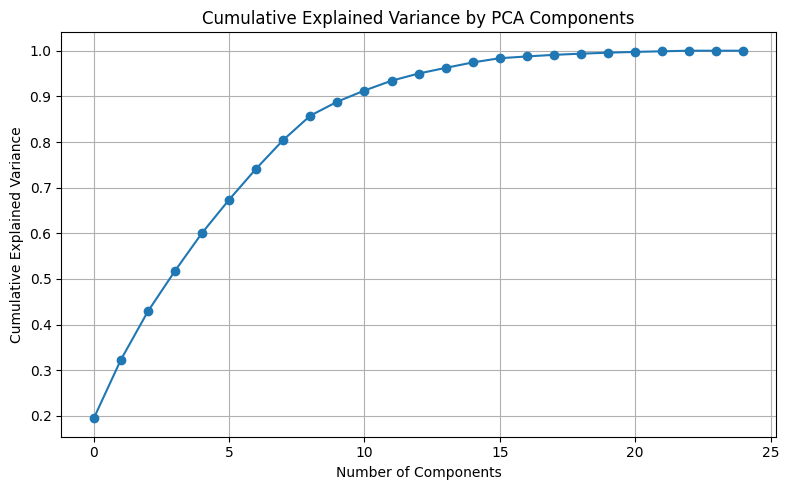

In [22]:
# Scree plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_var), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

**Variance Growth:**

As expected, the cumulative explained variance increases as the number of PCA components increases. This indicates that each additional component captures more variability in the data.

**Diminishing Returns:**

After approximately 8 components, the rate of increase in explained variance slows down. This suggests diminishing returns in the contribution of additional components to explaining the variability.

**Importance:**

The first five components explain around 68% of the variability in the data. Notably, the first three components account for approximately 50% of the explained variance in the dataset.

### Profiles

#### PC1

In [23]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC1'].sort_values(ascending=False)
print("\nCorrelation of variables with PC1:")
print(correlations)


Correlation of variables with PC1:
VALUE                  0.571132
MORTDUE                0.523312
CLNO                   0.411842
LOAN                   0.316581
CLAGE                  0.237527
DEBTINC                0.198380
NINQ                   0.081184
JOB_ProfExe            0.077822
YOJ                    0.051337
REASON_DebtCon         0.050983
JOB_Mgr                0.022529
DELINQ                 0.021980
DEROG_missing          0.014830
JOB_Self               0.011990
JOB_Sales              0.001803
VALUE_missing         -0.000544
DELINQ_missing        -0.001244
REASON_Not Provided   -0.002315
NINQ_missing          -0.003868
JOB_Office            -0.007254
JOB_Not Provided      -0.010843
DEBTINC_missing       -0.029959
REASON_HomeImp        -0.048669
DEROG                 -0.049192
JOB_Other             -0.096047
Name: PC1, dtype: float64


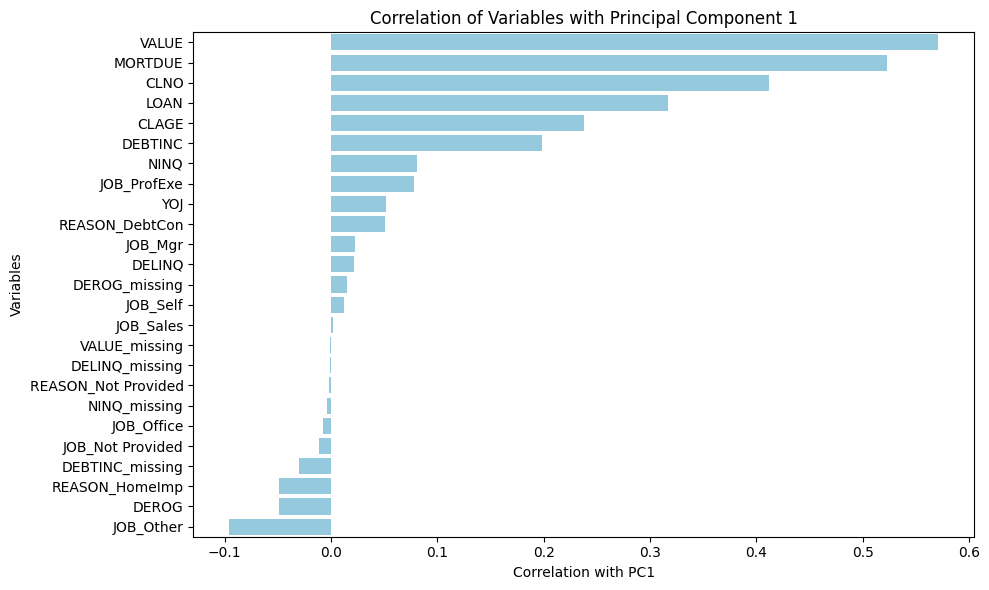

In [24]:
# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 1')
plt.xlabel('Correlation with PC1')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

***PC1: Financial Stability and Credit Activity***

**Key Variables:**
Strong positive correlations with VALUE, MORTDUE, and CLNO. Moderate correlations with NINQ, YOJ, and JOB_ProfExe.


**Profile:**
Individuals with higher property values, larger outstanding mortgage balances, and more credit lines. Typically exhibit moderate levels of recent credit inquiries and stable employment histories, often in professional or executive roles.

#### PC2

In [25]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC2'].sort_values(ascending=False)
print("\nCorrelation of variables with PC2:")
print(correlations)


Correlation of variables with PC2:
NINQ                   0.505451
DEROG                  0.483353
DELINQ                 0.410151
DEBTINC                0.365181
CLNO                   0.184019
DEBTINC_missing        0.113814
REASON_DebtCon         0.050081
JOB_Other              0.035886
JOB_Mgr                0.022878
VALUE_missing          0.012806
DEROG_missing          0.008538
MORTDUE                0.003012
JOB_Sales              0.001676
JOB_Self              -0.000401
DELINQ_missing        -0.004773
REASON_Not Provided   -0.004925
JOB_Not Provided      -0.005667
JOB_Office            -0.009729
NINQ_missing          -0.012354
JOB_ProfExe           -0.044644
REASON_HomeImp        -0.045156
VALUE                 -0.098234
LOAN                  -0.116375
YOJ                   -0.226750
CLAGE                 -0.280991
Name: PC2, dtype: float64


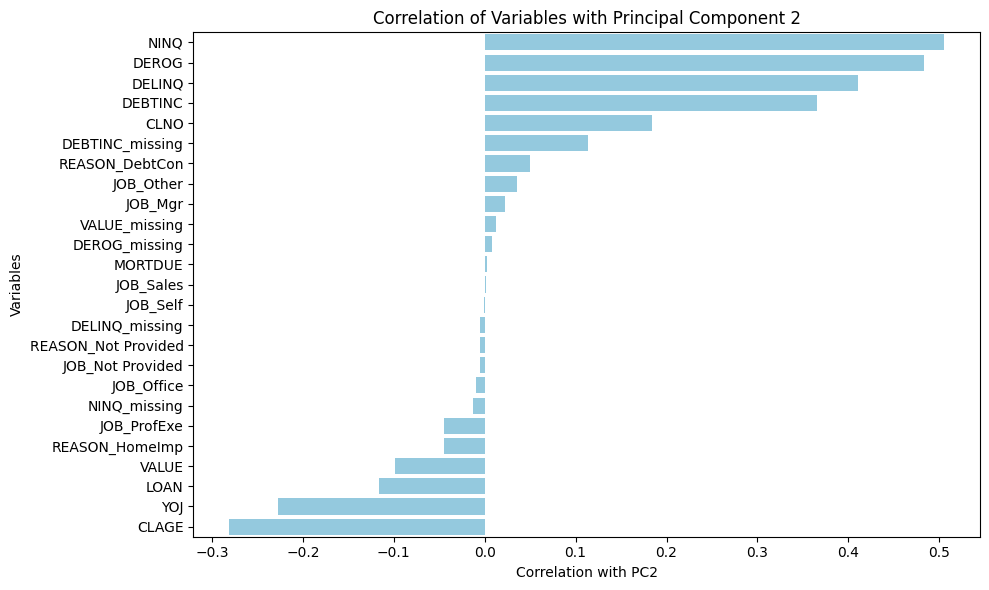

In [26]:
# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 2')
plt.xlabel('Correlation with PC2')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

***PC2: Credit Risk and Recent Financial Behavior***

**Key Variables:**
Strong positive correlations with NINQ, DEROG, and DELINQ. Moderate correlations with REASON_DebtCon and JOB_Other.

**Profile:**
Individuals with a high number of recent credit inquiries, past derogatory credit marks, and delinquent accounts. Likely to be consolidating debt and employed in roles outside of professional or executive categories, indicating a potential profile of higher credit risk and financial stress.

#### PC3

In [27]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC3'].sort_values(ascending=False)
print("\nCorrelation of variables with PC3:")
print(correlations)


Correlation of variables with PC3:
DELINQ                 0.497494
YOJ                    0.492643
CLAGE                  0.491219
CLNO                   0.287701
DEROG                  0.218075
DEBTINC_missing        0.047852
REASON_HomeImp         0.047612
JOB_ProfExe            0.018240
VALUE_missing          0.010059
REASON_Not Provided    0.009170
DEROG_missing          0.008912
JOB_Other              0.003357
NINQ_missing           0.002505
JOB_Mgr                0.001305
JOB_Sales             -0.000592
JOB_Self              -0.003817
JOB_Not Provided      -0.006288
JOB_Office            -0.012205
DELINQ_missing        -0.018214
LOAN                  -0.030423
REASON_DebtCon        -0.056782
NINQ                  -0.099999
VALUE                 -0.118222
DEBTINC               -0.210011
MORTDUE               -0.245436
Name: PC3, dtype: float64


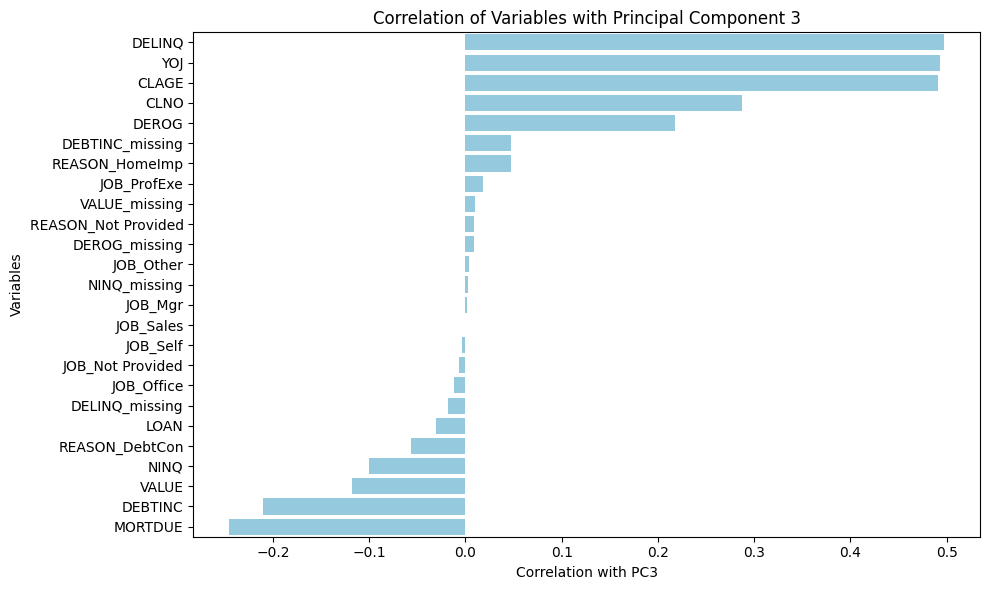

In [28]:
# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 3')
plt.xlabel('Correlation with PC3')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

***PC3: Credit History and Employment Tenure***

**Key Variables:**
Strong positive correlations with DELINQ, CLAGE, and YOJ. Moderate correlations with DEBTINC_missing and REASON_HomeImp.

**Profile:**
Individuals showing a history of delinquency but with relatively older credit accounts and longer job tenure. Some missing data on debt-to-income ratios and an association with home improvement as a loan purpose may suggest a mixed financial profile—possibly stable employment but past credit issues.



#### PC4

In [29]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC4'].sort_values(ascending=False)
print("\nCorrelation of variables with PC4:")
print(correlations)


Correlation of variables with PC4:
LOAN                   0.581247
YOJ                    0.446722
NINQ                   0.427701
DEBTINC                0.187262
REASON_DebtCon         0.131155
JOB_Other              0.092083
DELINQ_missing         0.008049
JOB_Mgr                0.003643
JOB_Self               0.002904
VALUE_missing         -0.003480
JOB_Not Provided      -0.007176
REASON_Not Provided   -0.007326
DEROG_missing         -0.008220
JOB_Sales             -0.009312
DEROG                 -0.014237
CLAGE                 -0.018101
NINQ_missing          -0.019324
DEBTINC_missing       -0.022500
JOB_Office            -0.024275
JOB_ProfExe           -0.057866
CLNO                  -0.112829
REASON_HomeImp        -0.123828
VALUE                 -0.126023
MORTDUE               -0.287916
DELINQ                -0.293884
Name: PC4, dtype: float64


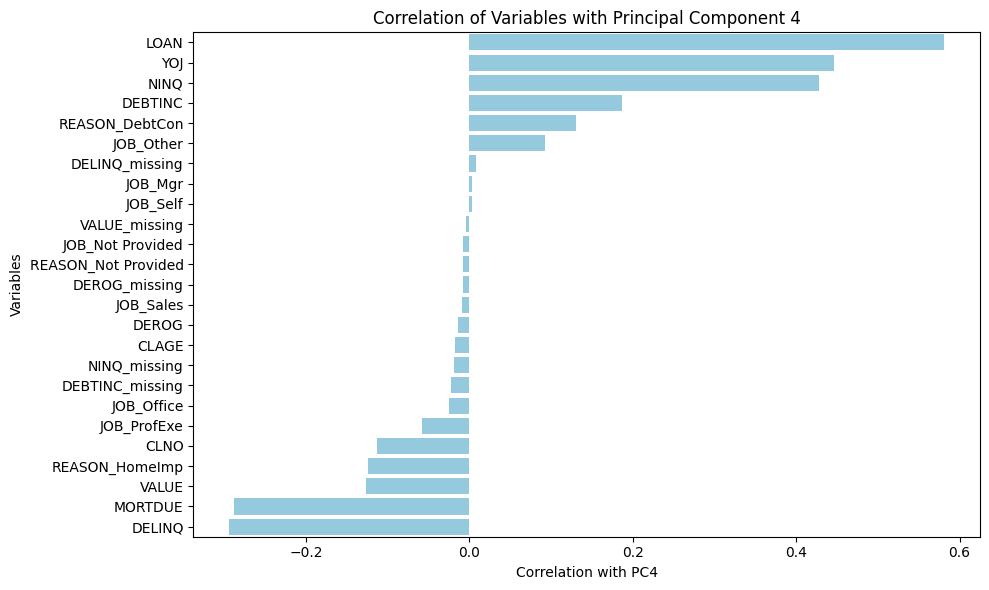

In [30]:
# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 4')
plt.xlabel('Correlation with PC4')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

***PC4: Loan Demand and Employment Duration***

**Key Variables:**
Strong positive correlations with LOAN, YOJ, and NINQ. Moderate correlations with REASON_DebtCon and JOB_Other.

**Profile:**
Strong positive correlations with LOAN, YOJ, and NINQ. Moderate correlations with REASON_DebtCon and JOB_Other.

#### PC5

In [31]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC5'].sort_values(ascending=False)
print("\nCorrelation of variables with PC5:")
print(correlations)


Correlation of variables with PC5:
DEROG                  0.570804
LOAN                   0.441847
VALUE                  0.183689
MORTDUE                0.066938
DELINQ                 0.057116
REASON_DebtCon         0.050412
JOB_ProfExe            0.032138
NINQ_missing           0.019768
JOB_Self               0.013825
JOB_Not Provided       0.013718
VALUE_missing          0.012492
REASON_Not Provided    0.010819
DELINQ_missing         0.008068
JOB_Mgr                0.000338
JOB_Sales             -0.002746
DEBTINC_missing       -0.008819
JOB_Office            -0.021138
JOB_Other             -0.036135
DEROG_missing         -0.037729
REASON_HomeImp        -0.061231
NINQ                  -0.136779
YOJ                   -0.150726
CLAGE                 -0.168154
CLNO                  -0.234698
DEBTINC               -0.548626
Name: PC5, dtype: float64


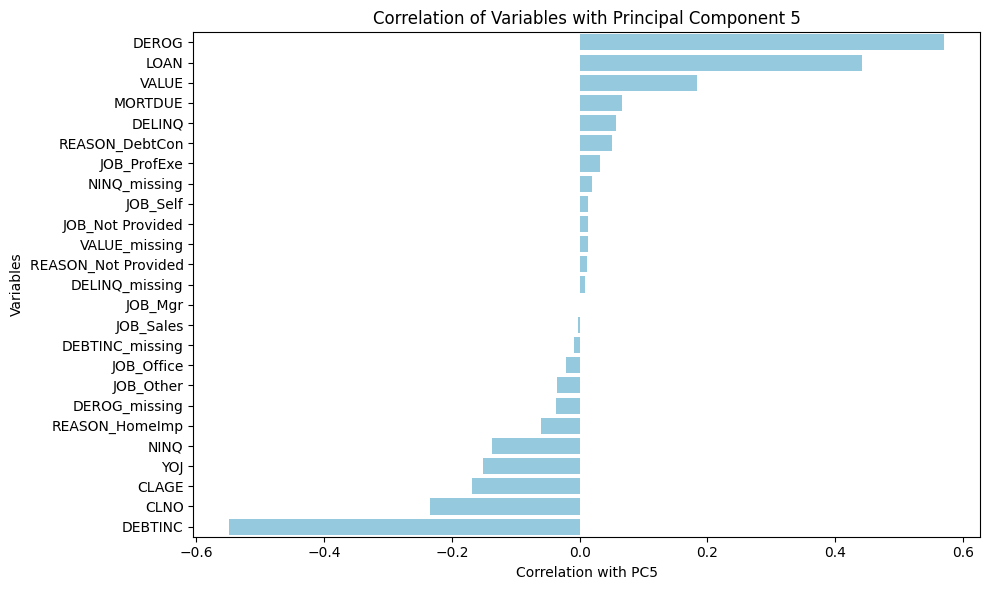

In [32]:
# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 5')
plt.xlabel('Correlation with PC5')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

***PC5: Adverse Credit Markers and Asset-Backed Borrowing***

**Key Variables:**
Strong positive correlations with DEROG, LOAN, and VALUE. Moderate correlations with MORTDUE, REASON_DebtCon, and DELINQ.

**Profile:**
Individuals with derogatory credit marks and substantial loan amounts, often backed by high-value properties. Moderate mortgage balances and debt consolidation purposes indicate a credit profile shaped by both significant borrowing and prior financial difficulties.

#### PC6

In [33]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC6'].sort_values(ascending=False)
print("\nCorrelation of variables with PC6:")
print(correlations)


Correlation of variables with PC6:
YOJ                    0.646657
MORTDUE                0.268377
DELINQ                 0.207243
VALUE                  0.184045
REASON_HomeImp         0.070313
DEBTINC                0.057986
DEBTINC_missing        0.037560
JOB_Mgr                0.027068
JOB_ProfExe            0.021533
VALUE_missing          0.005004
JOB_Self               0.004713
JOB_Not Provided       0.004365
DEROG_missing          0.000503
NINQ_missing          -0.001594
REASON_Not Provided   -0.002554
JOB_Sales             -0.006268
DELINQ_missing        -0.013295
JOB_Office            -0.022255
DEROG                 -0.029064
JOB_Other             -0.029155
REASON_DebtCon        -0.067760
NINQ                  -0.120879
LOAN                  -0.174536
CLNO                  -0.229967
CLAGE                 -0.563063
Name: PC6, dtype: float64


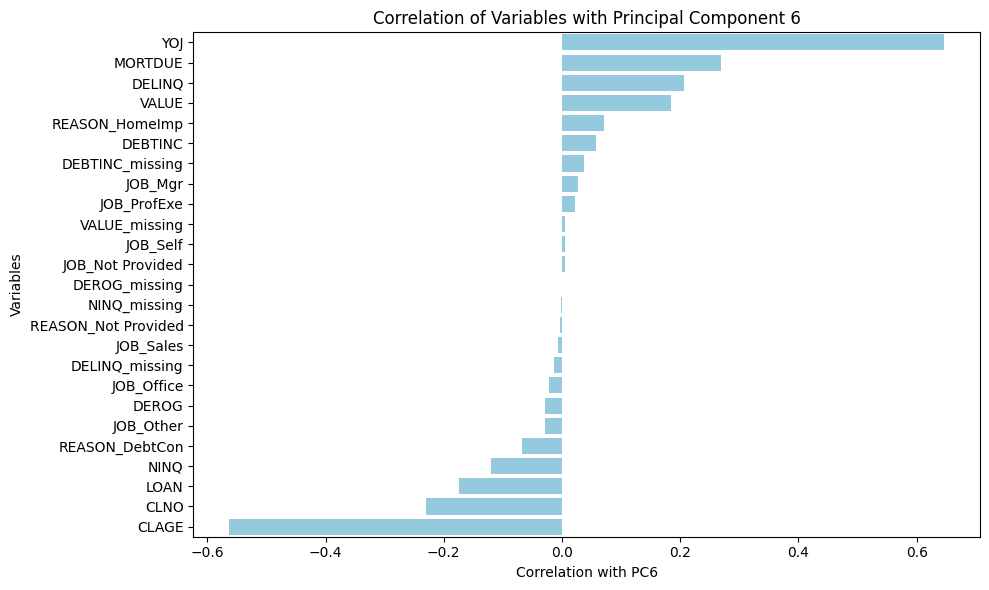

In [34]:
# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 6')
plt.xlabel('Correlation with PC6')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

***PC6: Employment Stability vs. Credit Maturity***

**Key Variables:**
Strong positive correlation with YOJ (Years on Job), followed by moderate positive correlations with MORTDUE, DELINQ, and VALUE. Strong negative correlations with CLAGE and CLNO.

**Profile:**
Individuals with long-term employment and moderate mortgage/property values, but with shorter credit histories and fewer open credit lines. This component contrasts job stability with limited or less mature credit profiles, suggesting relatively newer or rebuilding credit users despite employment longevity.

#### PC7

In [35]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC7'].sort_values(ascending=False)
print("\nCorrelation of variables with PC7:")
print(correlations)


Correlation of variables with PC7:
NINQ                   0.617968
MORTDUE                0.173911
YOJ                    0.133285
CLNO                   0.126727
JOB_ProfExe            0.072138
VALUE                  0.038161
CLAGE                  0.032435
REASON_HomeImp         0.028765
DEBTINC_missing        0.019326
JOB_Not Provided       0.008562
REASON_Not Provided    0.000581
JOB_Sales             -0.001915
JOB_Mgr               -0.002366
JOB_Self              -0.004345
DELINQ_missing        -0.006598
VALUE_missing         -0.008111
DEROG_missing         -0.013162
DEROG                 -0.017183
NINQ_missing          -0.022082
REASON_DebtCon        -0.029346
JOB_Office            -0.029659
JOB_Other             -0.042416
DELINQ                -0.283393
LOAN                  -0.372880
DEBTINC               -0.566634
Name: PC7, dtype: float64


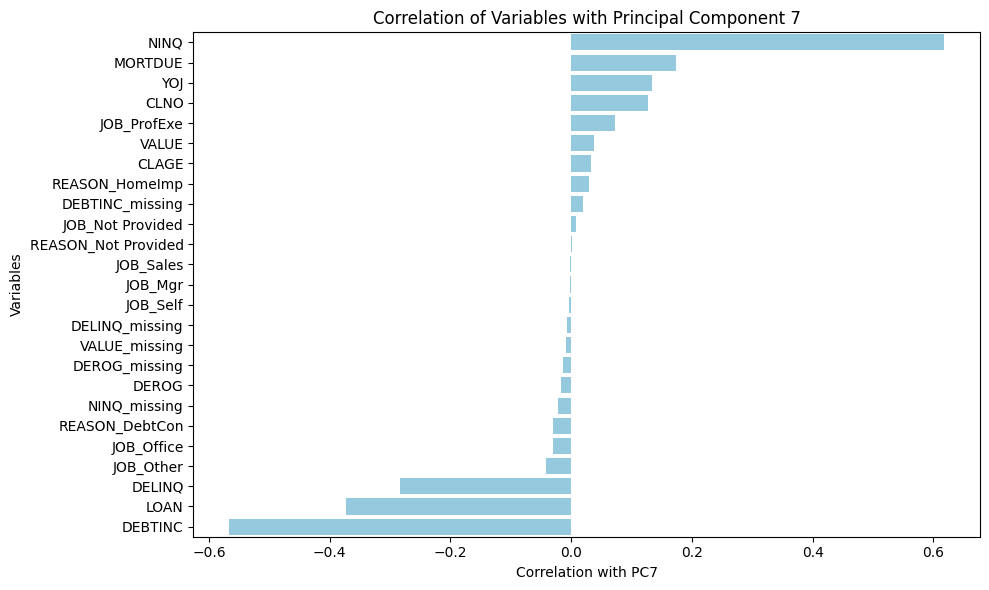

In [36]:
# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 7')
plt.xlabel('Correlation with PC7')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

***PC7: Recent Credit Activity vs. Debt Burden***

**Key Variables:**
Strong positive correlation with NINQ, with moderate positive associations with MORTDUE, CLNO, and YOJ. Strong negative correlations with DEBTINC, LOAN, and DELINQ.

**Profile:**
Individuals actively seeking new credit (high inquiries) and showing some mortgage and credit line activity, but with relatively low existing loan burdens, debt-to-income ratios, and fewer delinquencies. This component may reflect a segment of proactive borrowers with low current debt, potentially indicating financial optimism or planning for future credit needs.

#### PC8

In [37]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC8'].sort_values(ascending=False)
print("\nCorrelation of variables with PC8:")
print(correlations)


Correlation of variables with PC8:
DEROG                  0.615752
DEBTINC                0.305330
CLAGE                  0.198847
YOJ                    0.179402
REASON_HomeImp         0.120946
VALUE                  0.045357
MORTDUE                0.044044
JOB_Other              0.018926
DELINQ_missing         0.014461
NINQ_missing           0.011992
JOB_Sales              0.011452
REASON_Not Provided    0.001025
JOB_Self              -0.000825
JOB_ProfExe           -0.002041
JOB_Not Provided      -0.002996
VALUE_missing         -0.005274
DEBTINC_missing       -0.007107
JOB_Mgr               -0.007164
CLNO                  -0.015462
JOB_Office            -0.017352
DEROG_missing         -0.040651
REASON_DebtCon        -0.121971
NINQ                  -0.194191
LOAN                  -0.274346
DELINQ                -0.553391
Name: PC8, dtype: float64


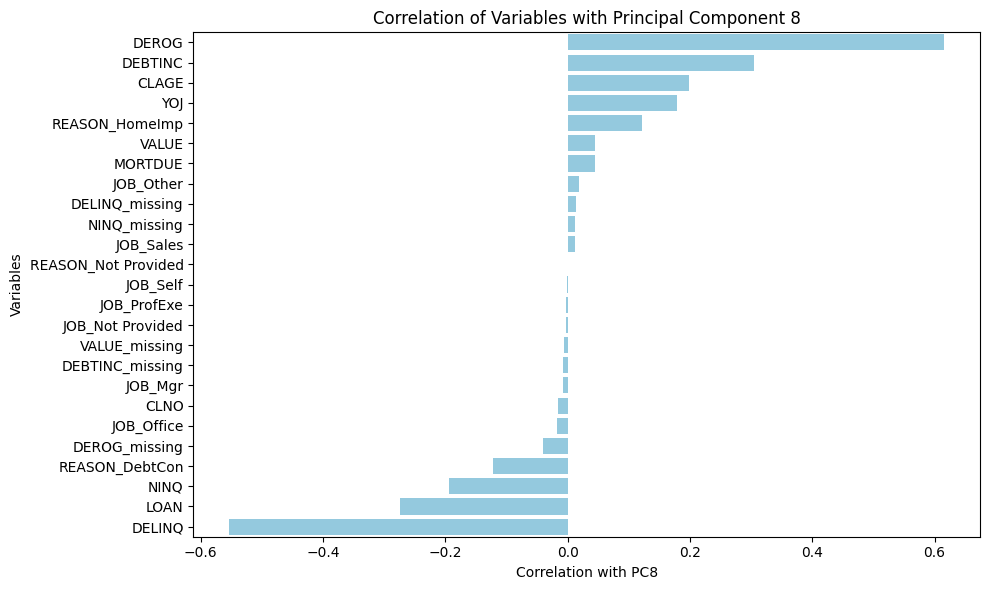

In [38]:
# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 8')
plt.xlabel('Correlation with PC8')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

***PC8: Adverse Credit Behavior vs. Responsible Credit Aging***

**Key Variables:**
Strong positive correlation with DEROG, with moderate positive correlations to DEBTINC, CLAGE, and YOJ. Strong negative correlations with DELINQ, LOAN, and NINQ.

**Profile:**
Individuals showing signs of past derogatory credit issues and moderate debt-to-income levels, but with longer credit histories and stable employment. This component contrasts legacy credit problems with a reduced incidence of recent delinquencies, new credit inquiries, or large loans—possibly reflecting efforts at financial recovery or stabilization after prior credit setbacks.

#### PC14


Correlation of variables with PC8:
JOB_Mgr                0.630965
DEBTINC_missing        0.617964
LOAN                   0.046680
JOB_Self               0.035027
VALUE_missing          0.029905
DELINQ_missing         0.029474
CLAGE                  0.028068
NINQ_missing           0.027435
MORTDUE                0.021551
REASON_HomeImp         0.018886
REASON_Not Provided    0.015290
JOB_Sales              0.014535
DEROG_missing          0.012152
CLNO                   0.011549
JOB_Not Provided       0.011110
YOJ                   -0.024163
DEBTINC               -0.027535
VALUE                 -0.028528
REASON_DebtCon        -0.034177
NINQ                  -0.050596
DEROG                 -0.050679
DELINQ                -0.070485
JOB_Other             -0.098690
JOB_ProfExe           -0.216879
JOB_Office            -0.376069
Name: PC14, dtype: float64


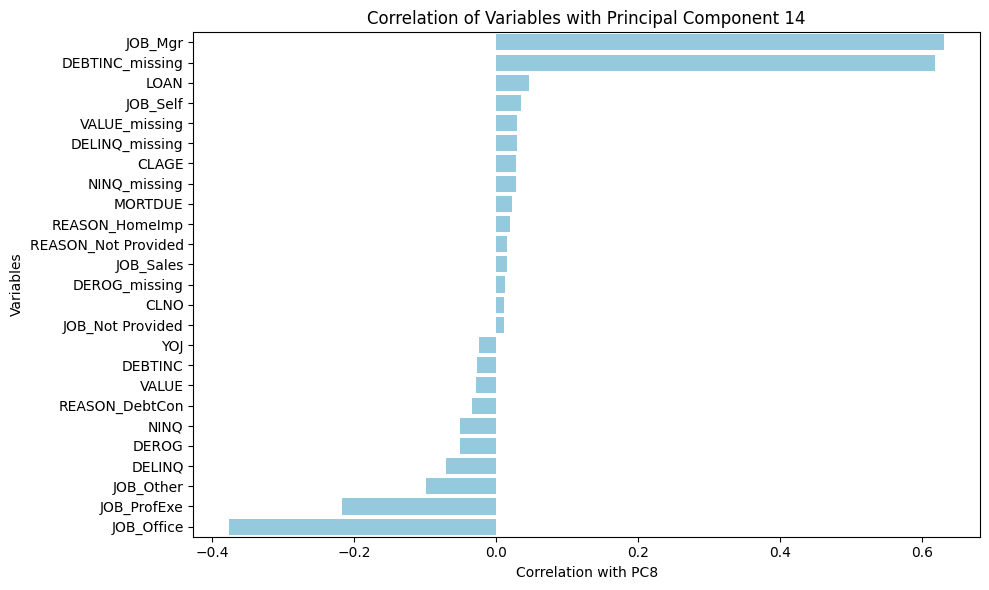

In [39]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC14'].sort_values(ascending=False)
print("\nCorrelation of variables with PC8:")
print(correlations)

# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 14')
plt.xlabel('Correlation with PC8')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

#### PC15


Correlation of variables with PC8:
DEBTINC_missing        0.736450
JOB_Office             0.428403
MORTDUE                0.095722
LOAN                   0.062137
JOB_Other              0.061707
VALUE_missing          0.031074
YOJ                    0.016690
CLNO                   0.013218
CLAGE                  0.013204
REASON_DebtCon         0.010975
REASON_Not Provided    0.007025
JOB_Self               0.006262
JOB_Sales              0.001827
JOB_ProfExe           -0.006743
JOB_Not Provided      -0.016123
REASON_HomeImp        -0.018001
DEBTINC               -0.019414
DEROG                 -0.027715
NINQ                  -0.041653
VALUE                 -0.052423
NINQ_missing          -0.053782
DELINQ                -0.060256
DELINQ_missing        -0.062956
DEROG_missing         -0.113085
JOB_Mgr               -0.475334
Name: PC15, dtype: float64


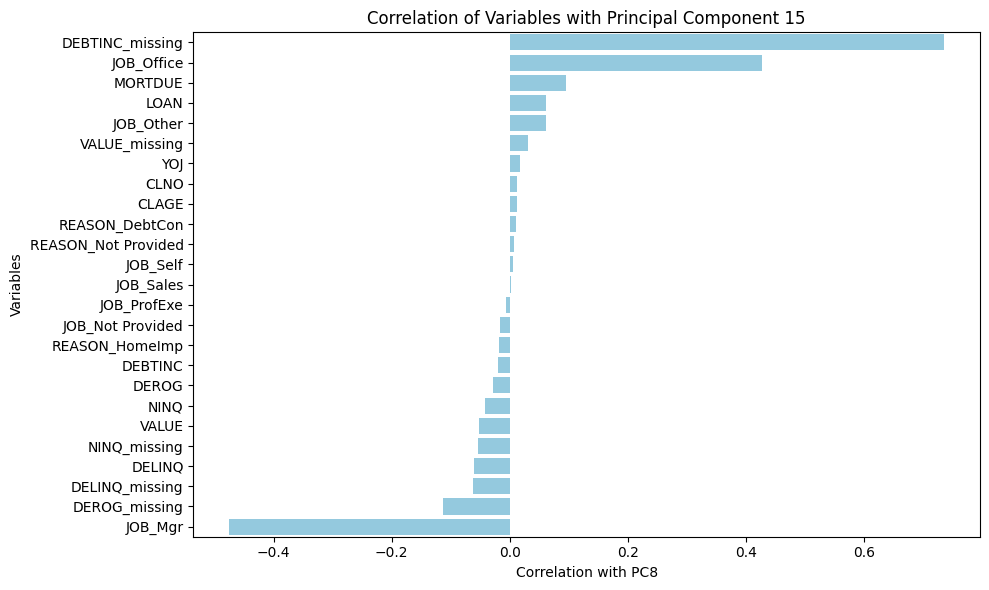

In [40]:
# PCA component loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Correlation between original variables and the first principal component
correlations = loadings['PC15'].sort_values(ascending=False)
print("\nCorrelation of variables with PC8:")
print(correlations)

# Plot correlations
plt.figure(figsize=(10,6))
sns.barplot(x=correlations.values, y=correlations.index, color='skyblue')
plt.title('Correlation of Variables with Principal Component 15')
plt.xlabel('Correlation with PC8')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Correlation matrix to see similarity with objective variable
full_data = df[X.columns.tolist() + ['BAD']]
corr_matrix = full_data.corr()

### Correlation With Objective Variable

In [41]:
# Calculate correlations between PCs and the objective variable
correlations = []
for i in range(X_pca.shape[1]):
    corr = np.corrcoef(X_pca[:, i], y)[0, 1]
    correlations.append(corr)

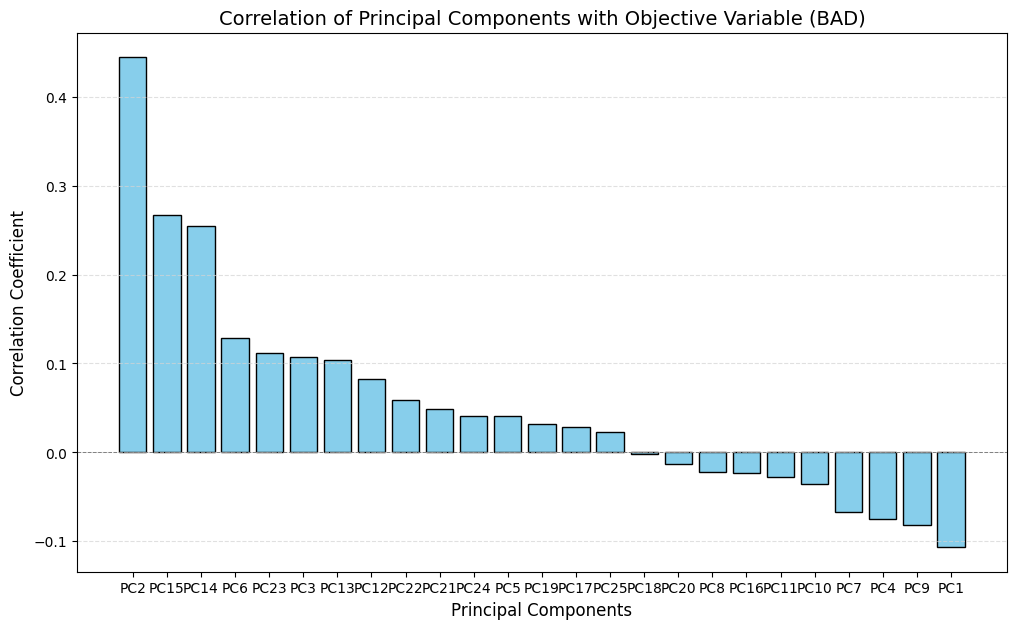

In [42]:
pc_indices = [f"PC{i+1}" for i in range(len(correlations))]

# Sort correlations and their corresponding PCs in descending order
sorted_indices = np.argsort(correlations)[::-1]
sorted_correlations = [correlations[i] for i in sorted_indices]
sorted_pc_indices = [pc_indices[i] for i in sorted_indices]

# Plot the sorted correlations
plt.figure(figsize=(12, 7))
plt.bar(sorted_pc_indices, sorted_correlations, color='skyblue', edgecolor='black')
plt.axhline(0, color='gray', linewidth=0.7, linestyle='--')

# Adding labels and title
plt.title('Correlation of Principal Components with Objective Variable (BAD)', fontsize=14)
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.grid(axis='y', linestyle='--', color='lightgray', alpha=0.7)

plt.show()


Correlation of each variable with objective variable:
DEBTINC_missing        0.543932
DELINQ                 0.354717
DEROG                  0.292455
VALUE_missing          0.253328
NINQ                   0.172380
DEBTINC                0.146337
JOB_Other              0.063512
JOB_Sales              0.052558
JOB_Self               0.040467
JOB_Mgr                0.033604
REASON_HomeImp         0.028017
REASON_Not Provided    0.024814
CLNO                  -0.009825
REASON_DebtCon        -0.036174
JOB_Not Provided      -0.041411
JOB_ProfExe           -0.047592
YOJ                   -0.055541
NINQ_missing          -0.058503
MORTDUE               -0.073808
JOB_Office            -0.082784
DELINQ_missing        -0.088023
VALUE                 -0.093138
DEROG_missing         -0.094047
LOAN                  -0.132839
CLAGE                 -0.181582
Name: BAD, dtype: float64


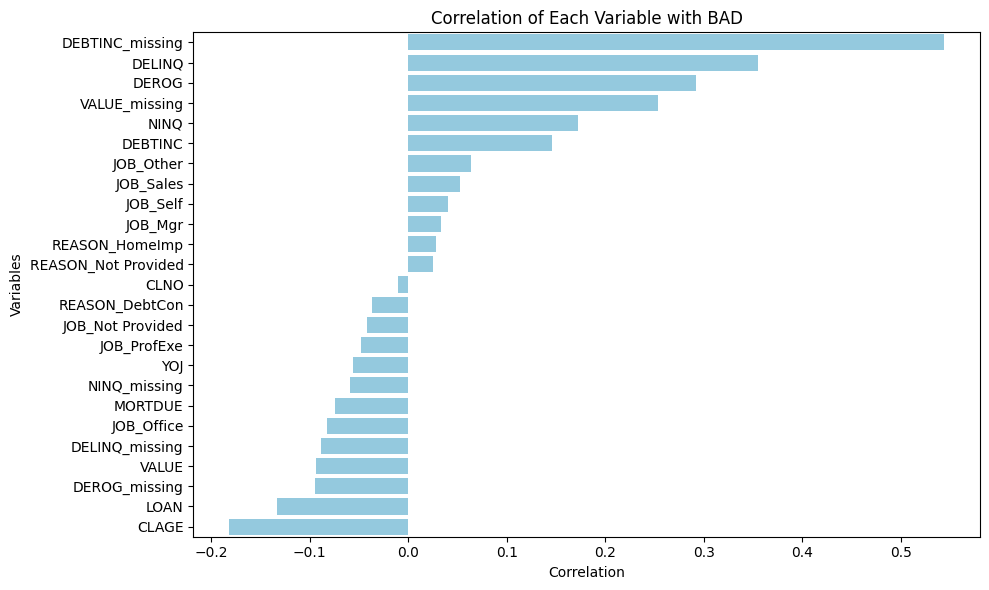

In [43]:
objective_var = 'BAD'

# Correlation with objective variable
obj_corr = corr_matrix[objective_var].drop(objective_var).sort_values(ascending=False)
print("\nCorrelation of each variable with objective variable:")
print(obj_corr)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=obj_corr.values, y=obj_corr.index, color='skyblue')
plt.title(f'Correlation of Each Variable with {objective_var}')
plt.xlabel('Correlation')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

### Others + Circle

In [44]:
predictors_scaled = X
target = y
explained_variance = pca.explained_variance_ratio_
print("Explained Variance by Principal Components:", explained_variance)

# Calculate correlation between PCs and target variable
pca_scores = pd.DataFrame(pca.transform(predictors_scaled))
pca_scores["UnitSales"] = target.values
correlations = pca_scores.corr()["UnitSales"][:-1]
correlation_rank = correlations.abs().sort_values(ascending=False)
print("Correlation with Target Variable (Ranked):")
print(correlation_rank)

Explained Variance by Principal Components: [1.94565564e-01 1.28133165e-01 1.06186423e-01 8.87347741e-02
 8.30700687e-02 7.29591350e-02 6.80167321e-02 6.28176522e-02
 5.32491957e-02 3.07112553e-02 2.43538241e-02 2.14649149e-02
 1.57629224e-02 1.24015693e-02 1.19064732e-02 9.25263277e-03
 3.82829147e-03 3.56145022e-03 2.54935090e-03 2.15174372e-03
 1.72835969e-03 1.36239190e-03 1.23211085e-03 8.93198210e-18
 0.00000000e+00]
Correlation with Target Variable (Ranked):
1     0.444371
14    0.266482
13    0.254380
5     0.128470
22    0.112103
2     0.107350
0     0.106633
12    0.103883
8     0.082137
11    0.081978
3     0.074884
6     0.067354
21    0.059009
20    0.048715
23    0.041209
4     0.040930
9     0.036035
18    0.032222
16    0.028676
10    0.027135
15    0.023478
24    0.022726
7     0.021503
19    0.013269
17    0.002324
Name: UnitSales, dtype: float64


In [45]:
predictors = X
# Identify contribution of each variable to PCs
loadings = pd.DataFrame(pca.components_.T, columns=[f"PC{i+1}" for i in range(pca.n_components_)], index=predictors.columns)

# Calculate overall contributions
weighted_contributions = (loadings.iloc[:, 0].abs() * correlation_rank.iloc[0]).sort_values(ascending=False)
contributions = pd.DataFrame({
        "Variable": weighted_contributions.index,
        "Weighted_Contribution": weighted_contributions.values
    }).sort_values(by="Weighted_Contribution", ascending=False)
print("Variable Contributions to Target Variability:")
print(contributions)

Variable Contributions to Target Variability:
               Variable  Weighted_Contribution
0                 VALUE               0.253794
1               MORTDUE               0.232545
2                  CLNO               0.183011
3                  LOAN               0.140679
4                 CLAGE               0.105550
5               DEBTINC               0.088154
6             JOB_Other               0.042681
7                  NINQ               0.036076
8           JOB_ProfExe               0.034582
9                   YOJ               0.022813
10       REASON_DebtCon               0.022655
11                DEROG               0.021860
12       REASON_HomeImp               0.021627
13      DEBTINC_missing               0.013313
14              JOB_Mgr               0.010011
15               DELINQ               0.009767
16        DEROG_missing               0.006590
17             JOB_Self               0.005328
18     JOB_Not Provided               0.004818
19           J

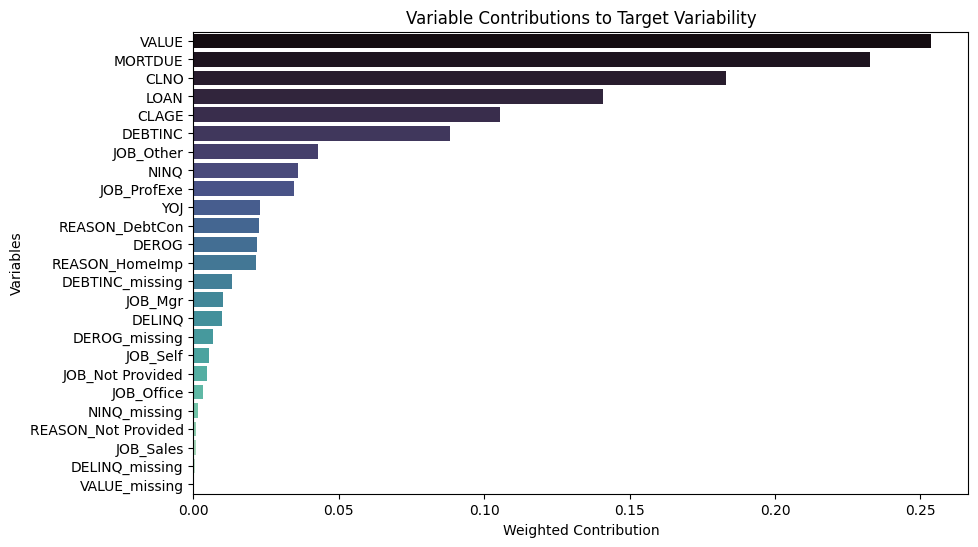

In [46]:
# Plot contributions
plt.figure(figsize=(10, 6))
sns.barplot(data=contributions, x="Weighted_Contribution", y="Variable", palette="mako")
plt.title("Variable Contributions to Target Variability")
plt.xlabel("Weighted Contribution")
plt.ylabel("Variables")
plt.show()

**Top Contributing Variables:**
VALUE, MORTDUE, and CLNO are the strongest contributors, indicating that financial indicators play a key role in explaining the target variable.

**Mid-Level Contributors:**
JOB_Other, JOB_ProfExe, YOJ, and NINQ contribute moderately, adding insights related to employment and credit characteristics.

**Lower-Level Contributors:**
VALUE_missing, DELINQ_missing, and JOB_Sales have minimal influence, suggesting they are less relevant or introduce noise.

**Categorical Variables:**
Variables like JOB_Other and REASON_HomeImp provide insight into employment and borrowing purposes, with moderate impact.

**Actionable Insights:**
Prioritize VALUE and MORTDUE for analysis, while considering the exclusion of lower-contributing variables like VALUE_missing and DELINQ_missing.

**Target Focus:**
The model is primarily driven by financial factors, particularly MORTDUE and VALUE.

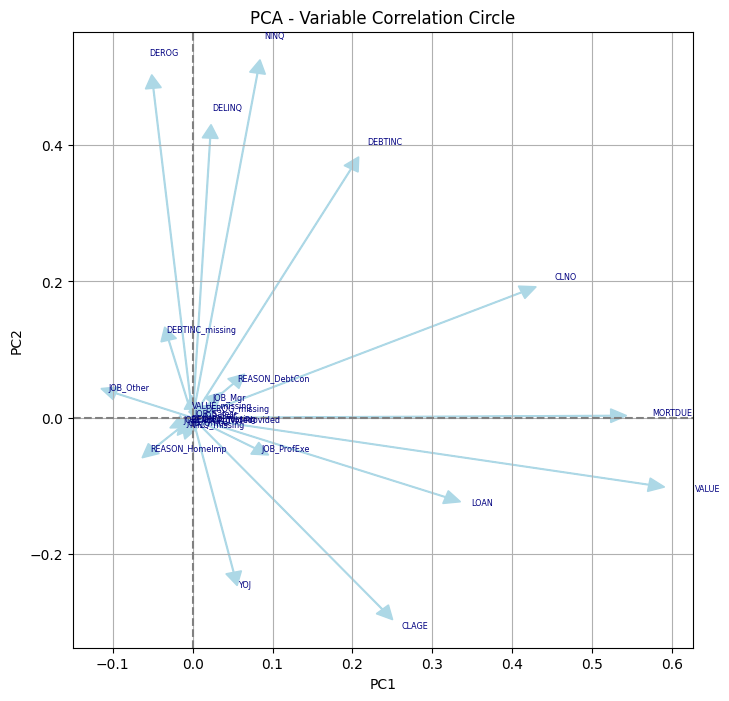

In [47]:
# PCA - Variable Correlation Circle
plt.figure(figsize=(8, 8))
for i, (x, y) in enumerate(zip(loadings.iloc[:, 0], loadings.iloc[:, 1])):
        plt.arrow(0, 0, x, y, head_width=0.02, head_length=0.02, color='lightblue')
        plt.text(x*1.1, y*1.1, loadings.index[i], color='navy', size = 'xx-small')
plt.title("PCA - Variable Correlation Circle")
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

**PC1 (Horizontal Axis):**
Variables like VALUE, MORTDUE, and CLNO show high positive loadings, indicating a strong relationship with PC1. These variables seem to represent key aspects of an individual's financial capacity and credit exposure. On the opposite side, REASON_HomeImp exhibits a slight negative loading, suggesting it contrasts with the more significant mortgage-related variables and could indicate a focus on smaller, more targeted borrowing for specific purposes like home improvement.

**PC2 (Vertical Axis):**
Variables such as DEROG, DELINQ, and NINQ load positively on PC2, reflecting their association with credit risk, like derogatory marks and delinquencies. JOB_Other has a negative loading, suggesting that it may separate less traditional employment categories from more common financial risk indicators.

**Clusters of Variables:**
There is a clear cluster of financial strength indicators, with VALUE, MORTDUE, and CLNO grouped together in the top-right quadrant, suggesting these variables tend to co-vary. The top-left quadrant, conversely, hosts the credit risk indicators (DEROG, DELINQ, NINQ), reflecting a strong connection between these variables. Additionally, variables like DEBTINC_missing and DELINQ_missing appear close to the center-top, highlighting a possible shared pattern related to missing data.

**Variables Near the Origin:**
Variables like YOJ, JOB_Self, and REASON_Not Provided lie near the origin, contributing minimally to the variance explained by PC1 and PC2. These variables seem to have a weaker influence on the overall patterns captured by the principal components.

**Interpretation of Principal Components:**
PC1 reflects a dichotomy between high financial capacity and more targeted borrowing, with a focus on larger financial assets (e.g., mortgages) versus smaller, purpose-specific loans like home improvement. PC2 captures a dimension of credit risk and missing data patterns, with a distinction between risky behaviors (e.g., delinquencies) and less-defined employment or missing data categories.